In [ ]:
import qiskit
import qiskit_machine_learning
import qiskit_aer

print("Qiskit:", qiskit.__version__)
print("Qiskit ML:", qiskit_machine_learning.__version__)
print("Qiskit Aer:", qiskit_aer.__version__)

Qiskit: 2.4.2
Qiskit ML: 0.9.0
Qiskit Aer: 0.17.2


# QSVC


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel


# SETTINGS

N_TRAIN = 1500 # Running the QSVC on the full 5700 training made the kernel crash. Using a reduced batch of 1500 images reduces the computational load 
               #and helped run the QSVC training without issues.

N_PCA = 4

SEED = 42


# LOAD DATA

X_train = np.load("data_Demo/X_train.npy")
y_train = np.load("data_Demo/y_train.npy")

X_test = np.load("data_Demo/X_test.npy")
y_test = np.load("data_Demo/y_test.npy")




print("Training pool:", X_train.shape)
print("Test set:", X_test.shape)

print("\nOriginal training distribution:")
print(np.bincount(y_train))

print("\nTest distribution:")
print(np.bincount(y_test))




idx = np.arange(len(X_train))

idx_train, _ = train_test_split(
    idx,
    train_size=N_TRAIN,
    stratify=y_train,
    random_state=SEED
)

X_train = X_train[idx_train]
y_train = y_train[idx_train]


print("\nSelected training distribution:")
print(np.bincount(y_train))

print("Selected training samples:", X_train.shape)


# PCA 

pca = PCA(n_components=N_PCA)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# SCALE TO [0, π] 

scaler = MinMaxScaler(feature_range=(0, np.pi))

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Reduced train shape:", X_train.shape)
print("Reduced test shape:", X_test.shape)



# FEATURE MAP
feature_map = zz_feature_map(
    feature_dimension=N_PCA,
    reps=1
)



#  QUANTUM KERNEL

quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map
)


#  QUANTUM KERNEL CALCULATION

print("\nCalculating quantum kernel...")

K_train = quantum_kernel.evaluate(
    X_train
)

print("Quantum kernel: DONE")


# QSVC

print("\nTraining QSVC...")

qsvc = SVC(
    kernel="precomputed",
    C=1.0
)

qsvc.fit(
    K_train,
    y_train
)

print("QSVC training: DONE")


# TEST KERNEL

print("\nCalculating test quantum kernel...")

K_test = quantum_kernel.evaluate(
    X_test,
    X_train
)

print("Test quantum kernel: DONE")

Training pool: (5712, 128)
Test set: (1311, 128)

Original training distribution:
[1321 1339 1595 1457]

Test distribution:
[300 306 405 300]

Selected training distribution:
[347 352 419 382]
Selected training samples: (1500, 128)
Reduced train shape: (1500, 4)
Reduced test shape: (1311, 4)

Calculating quantum kernel...
Quantum kernel: DONE

Training QSVC...
QSVC training: DONE

Calculating test quantum kernel...
Test quantum kernel: DONE



QSVC RESULTS
Training samples: 1500
Qubits: 4
Test accuracy: 98.55%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98       300
           1       0.96      0.99      0.98       306
           2       1.00      1.00      1.00       405
           3       0.97      1.00      0.99       300

    accuracy                           0.99      1311
   macro avg       0.98      0.98      0.98      1311
weighted avg       0.99      0.99      0.99      1311



<Figure size 700x600 with 0 Axes>

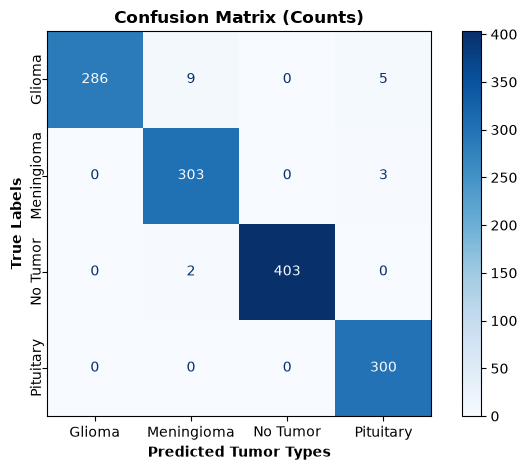

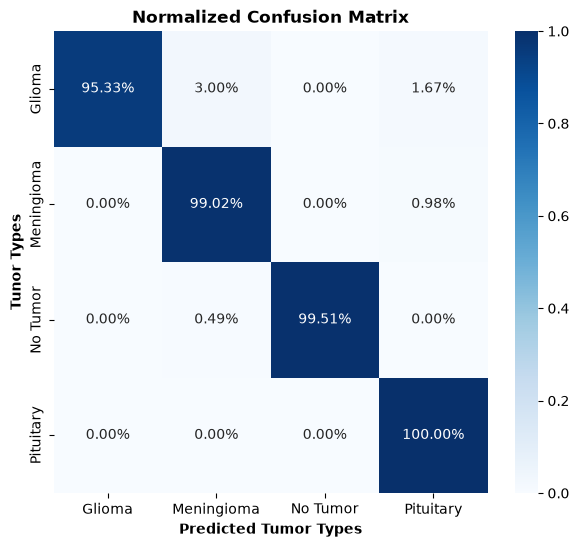

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import numpy as np
import seaborn as sns

# PREDICTION

y_pred = qsvc.predict(
    K_test
)


#  RESULTS

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n" + "=" * 50)
print("QSVC RESULTS")
print("=" * 50)

print(
    f"Training samples: {N_TRAIN}"
)

print(
    f"Qubits: {N_PCA}"
)

print(
    f"Test accuracy: {accuracy * 100:.2f}%"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)


# CONFUSION MATRIX



cm = confusion_matrix(y_test, y_pred)

CLASS_NAMES = [
    "Glioma",
    "Meningioma",
    "No Tumor",
    "Pituitary"
]

plt.figure(figsize=(7,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=CLASS_NAMES)

disp.plot(cmap="Blues", 
          values_format="d")

for label in disp.ax_.get_yticklabels():
    label.set_rotation(90)
    label.set_verticalalignment("center")
    label.set_horizontalalignment("center")

plt.title("Confusion Matrix (Counts)", fontweight="bold")
plt.xlabel("Predicted Tumor Types", fontweight="bold")
plt.ylabel("True Labels", fontweight="bold")
plt.tight_layout()

plt.show()


# Normalized Confusion Matrix


cm_percent = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7,6) )

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Tumor Types", fontweight="bold")
plt.ylabel("Tunor Types", fontweight="bold")
plt.title("Normalized Confusion Matrix", fontweight="bold")

plt.show()

In [9]:
print("Number of support vectors:", len(qsvc.support_))

Number of support vectors: 209


In [10]:
print("Support vectors per class:")
print(qsvc.n_support_)

Support vectors per class:
[34 65 46 64]


In [11]:
n_support = len(qsvc.support_)
support_fraction = n_support / len(y_train)

print("Total support vectors:", n_support)
print("Training samples:", len(y_train))
print(
    f"Support-vector fraction: "
    f"{support_fraction * 100:.2f}%"
)

Total support vectors: 209
Training samples: 1500
Support-vector fraction: 13.93%


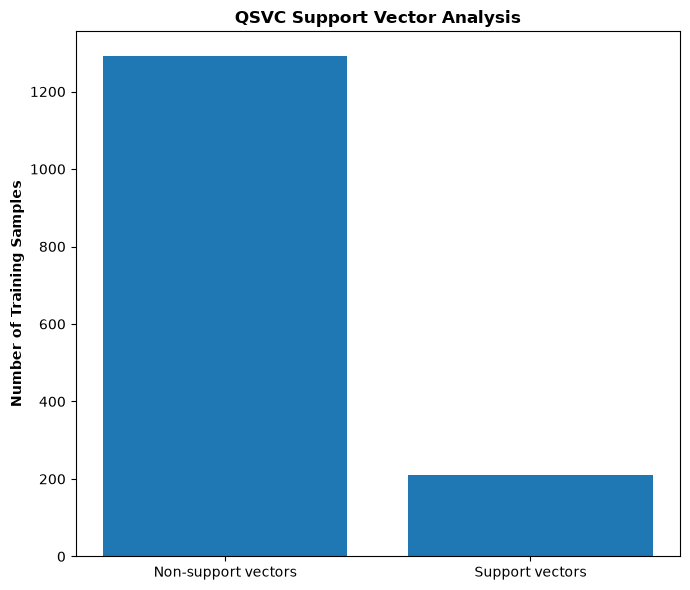

In [60]:
plt.figure(figsize=(7,6))

plt.bar(
    ["Non-support vectors", "Support vectors"],
    [
        len(y_train) - n_support,
        n_support
    ],
    
)
plt.ylabel("Number of Training Samples", fontweight="bold")
plt.title("QSVC Support Vector Analysis", fontweight="bold")

plt.tight_layout()
plt.show()

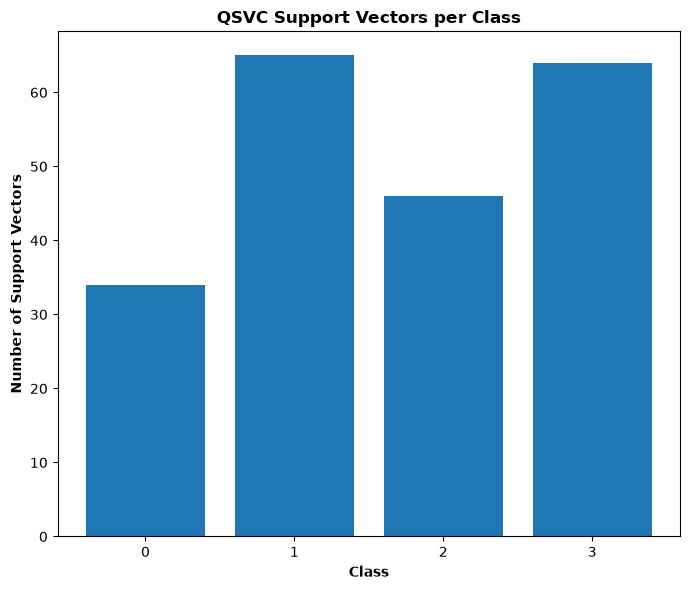

In [ ]:
# Support vectors per class

plt.figure(figsize=(7,6))

plt.bar(
    np.arange(len(qsvc.n_support_)),
    qsvc.n_support_
)

plt.xlabel("Class", fontweight="bold")
plt.ylabel("Number of Support Vectors", fontweight="bold")
plt.title("QSVC Support Vectors per Class", fontweight="bold")

plt.xticks(
    np.arange(len(qsvc.n_support_))
)

plt.tight_layout()
plt.show()

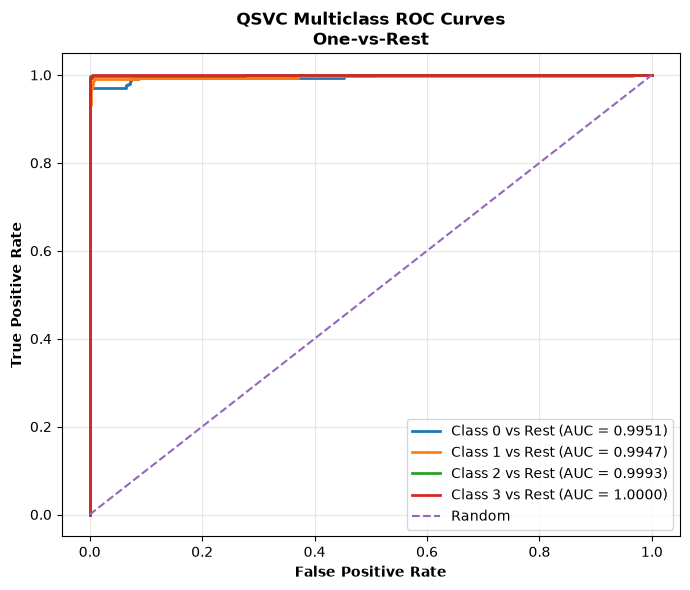

Macro ROC-AUC: 0.9973


In [ ]:
# ROC curve and AUC

import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score

classes = qsvc.classes_

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

decision_scores = qsvc.decision_function(K_test)

plt.figure(figsize=(7,6))

for i, c in enumerate(classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        decision_scores[:, i]
    )

    auc = roc_auc_score(
        y_test_bin[:, i],
        decision_scores[:, i]
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"Class {c} vs Rest (AUC = {auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate", fontweight="bold")
plt.ylabel("True Positive Rate", fontweight="bold")

plt.title(
    "QSVC Multiclass ROC Curves\n"
    "One-vs-Rest", fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


macro_auc = roc_auc_score(
    y_test_bin,
    decision_scores,
    average="macro"
)

print(
    f"Macro ROC-AUC: {macro_auc:.4f}"
)

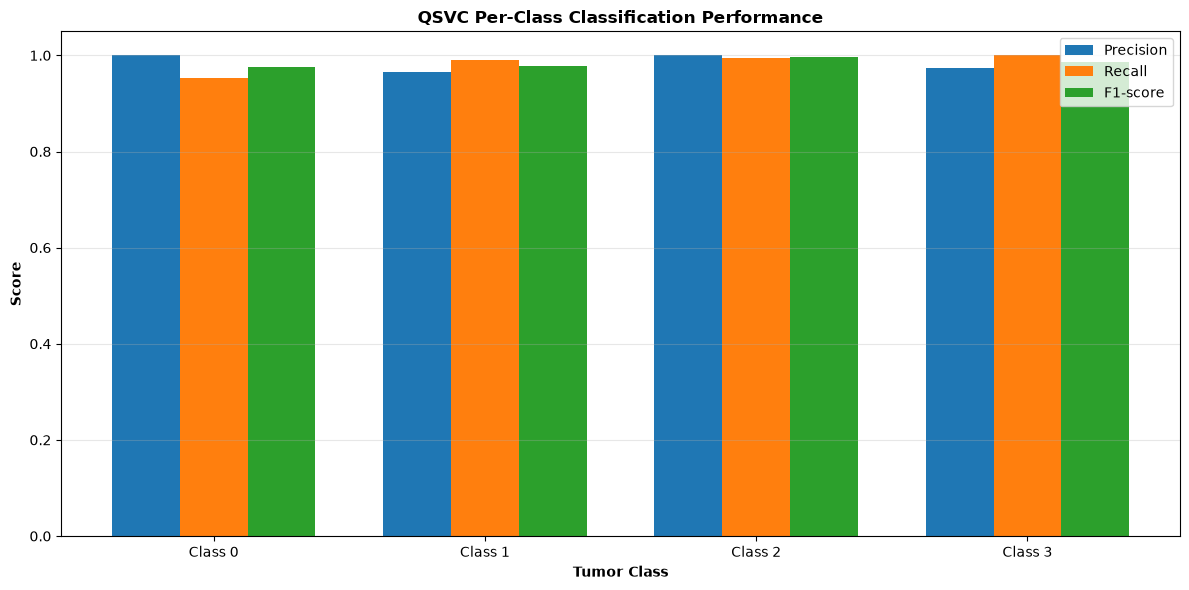

In [67]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import matplotlib.pyplot as plt

precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=np.unique(y_test),
    zero_division=0
)

classes = np.unique(y_test)

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(12,6))

plt.bar(
    x - width,
    precision,
    width,
    label="Precision"
)

plt.bar(
    x,
    recall,
    width,
    label="Recall"
)

plt.bar(
    x + width,
    f1,
    width,
    label="F1-score"
)

plt.xticks(
    x,
    [f"Class {c}" for c in classes]
)

plt.ylim(0, 1.05)
plt.xlabel("Tumor Class", fontweight="bold")
plt.ylabel("Score", fontweight="bold")
plt.title("QSVC Per-Class Classification Performance" , fontweight="bold")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()